In [1]:
import pandas as pd             # data package
import matplotlib.pyplot as plt # graphics 
import datetime as dt
import numpy as np
from scipy.stats.mstats import gmean

import matplotlib.ticker as mtick 

import requests, io             # internet and input tools  
import zipfile as zf            # zip file tools 
import os  

#import weightedcalcs as wc
#import numpy as np

import pyarrow as pa
import pyarrow.parquet as pq

In [104]:
file = "C:\\github\\median-tariff\\data\\imports-hs10\\TOTALdata-2024-12.parquet"

df = pq.read_table(file).to_pandas()

df["CAL_DUT_MO"] = df["CAL_DUT_MO"].astype(float)

df["CON_VAL_MO"] = df["CON_VAL_MO"].astype(float)

df.time = pd.to_datetime(df.time, format="%Y-%m")

df["applied_tariff"] = df["CAL_DUT_MO"] / df["CON_VAL_MO"]

foo = df.set_index("time").loc["2024"].copy()

totalimports = foo["CON_VAL_MO"].sum()

grp = foo.groupby("I_COMMODITY")

weights = grp["CON_VAL_MO"].sum() / totalimports

In [166]:
file = "C:\\github\\median-tariff\\data\\imports-hs10\\0003data-2024-12.parquet"

dfcntry = pq.read_table(file).to_pandas()

dfcntry["CAL_DUT_MO"] = dfcntry["CAL_DUT_MO"].astype(float)

dfcntry["CON_VAL_MO"] = dfcntry["CON_VAL_MO"].astype(float)

dfcntry.time = pd.to_datetime(dfcntry.time, format="%Y-%m")

dfcntry["applied_tariff"] = dfcntry["CAL_DUT_MO"] / dfcntry["CON_VAL_MO"]

In [167]:
dfcntry = pd.merge(dfcntry, weights.rename("weights"), how="left", on="I_COMMODITY", indicator=True)

In [168]:
dfcntry.head()

,CTY_NAME,CON_VAL_MO,CAL_DUT_MO,I_COMMODITY,I_COMMODITY_SDESC,time,COMM_LVL,CTY_CODE,applied_tariff,weights,_merge
0,EUROPEAN UNION,2649.0,269.0,0105990000,"POULTRY, LIVE, WEIGHING 185 G OR MORE EACH, NESOI",2025-06-01,HS10,0003,0.101548,0.000003,both
1,EUROPEAN UNION,0.0,0.0,0105990000,"POULTRY, LIVE, WEIGHING 185 G OR MORE EACH, NESOI",2025-07-01,HS10,0003,NaN,0.000003,both
2,EUROPEAN UNION,0.0,0.0,0105990000,"POULTRY, LIVE, WEIGHING 185 G OR MORE EACH, NESOI",2025-08-01,HS10,0003,NaN,0.000003,both
3,EUROPEAN UNION,9500.0,0.0,0106110000,"PRIMATES, LIVE",2013-08-01,HS10,0003,0.000000,0.000041,both
4,EUROPEAN UNION,0.0,0.0,0106110000,"PRIMATES, LIVE",2013-09-01,HS10,0003,NaN,0.000041,both


In [169]:
# Automate calculation for all dates
results = []

weights_sum = bar["weights"].sum()

for date in dfcntry['time'].unique():

    bar = dfcntry.set_index("time").loc[date].copy()
    
    meanweighted = (bar["applied_tariff"] * bar["weights"]).sum()

    squareweighted = ((bar["applied_tariff"]**2 * bar["weights"]).sum())**0.5

    mediantariff = bar["applied_tariff"].median()
    
    results.append({
        'time': date,
        'weights_sum': weights_sum,
        'mean_weighted': meanweighted,
        'square_weighted': squareweighted,
        'median': mediantariff,
    })

# Convert to DataFrame for easy viewing
results_df = pd.DataFrame(results).set_index('time').sort_index()
results_df

,weights_sum,mean_weighted,square_weighted,median
time,,,,
2013-01-01,0.801336,0.010801,0.034085,0.025968
2013-02-01,0.801336,0.010700,0.033844,0.026017
2013-03-01,0.801336,0.010946,0.034322,0.025998
2013-04-01,0.801336,0.010865,0.033925,0.025995
2013-05-01,0.801336,0.010870,0.034050,0.025997
...,...,...,...,...
2025-04-01,0.801336,0.053989,0.090010,0.065001
2025-05-01,0.801336,0.088807,0.126990,0.119996
2025-06-01,0.801336,0.099612,0.143681,0.127815


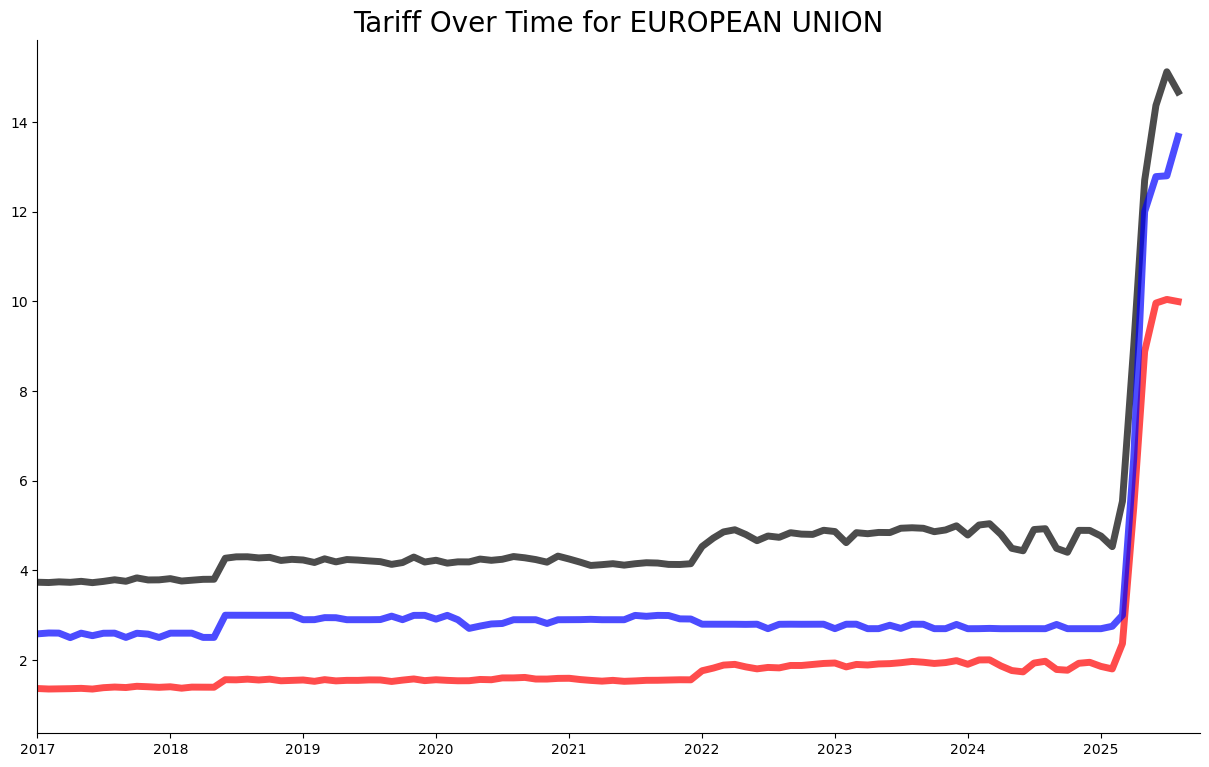

In [170]:
fig, ax = plt.subplots(figsize = (15,9))

ax.plot(results_df.index, 100*results_df["mean_weighted"], color = "red", alpha = 0.7, linewidth = 5)

ax.plot(results_df.index, 100*results_df["square_weighted"], color = "black", alpha = 0.7, linewidth = 5)

ax.plot(results_df.index, 100*results_df["median"], color = "blue", alpha = 0.7, linewidth = 5)

ax.set_title("Tariff Over Time for " + dfcntry["CTY_NAME"].iloc[0], fontsize = 20)

ax.set_xlim([dt.datetime(2017,1,1), dt.datetime(2025,9,30)])

ax.spines["right"].set_visible(False)

ax.spines["top"].set_visible(False)

plt.show()

In [143]:
grp = dfcntry.groupby("time")

meantariff = grp["applied_tariff"].mean()

mediantariff = grp["applied_tariff"].median()

trimmedmediantariff = grp["applied_tariff"].apply(trimmed_median)

tradeweighttariff = grp.apply(lambda x: x["CAL_DUT_MO"].sum() / x["CON_VAL_MO"].sum(), include_groups=False)

mode_tariff = grp['applied_tariff'].apply(lambda x: x.mode()[0] if len(x.mode()) > 0 else np.nan)

In [144]:
datetolookat = "2025-08"

print(meantariff.loc[datetolookat])

print(mediantariff.loc[datetolookat])

print(trimmedmediantariff.loc[datetolookat])

print(tradeweighttariff.loc[datetolookat])

print(mode_tariff.loc[datetolookat])

time
2025-08-01    0.19149
Name: applied_tariff, dtype: float64
time
2025-08-01    0.155258
Name: applied_tariff, dtype: float64
time
2025-08-01    0.149952
Name: applied_tariff, dtype: float64
time
2025-08-01    0.10552
dtype: float64
time
2025-08-01    0.0
Name: applied_tariff, dtype: float64


In [ ]:
def trimmed_median(x, lower_pct=0.05, upper_pct=0.95):
    """Remove bottom and top percentiles, then compute median"""
    lower_bound = x.quantile(lower_pct)
    upper_bound = x.quantile(upper_pct)
    trimmed = x[(x >= lower_bound) & (x <= upper_bound)]
    
    return trimmed.median() if len(trimmed) > 0 else np.nan



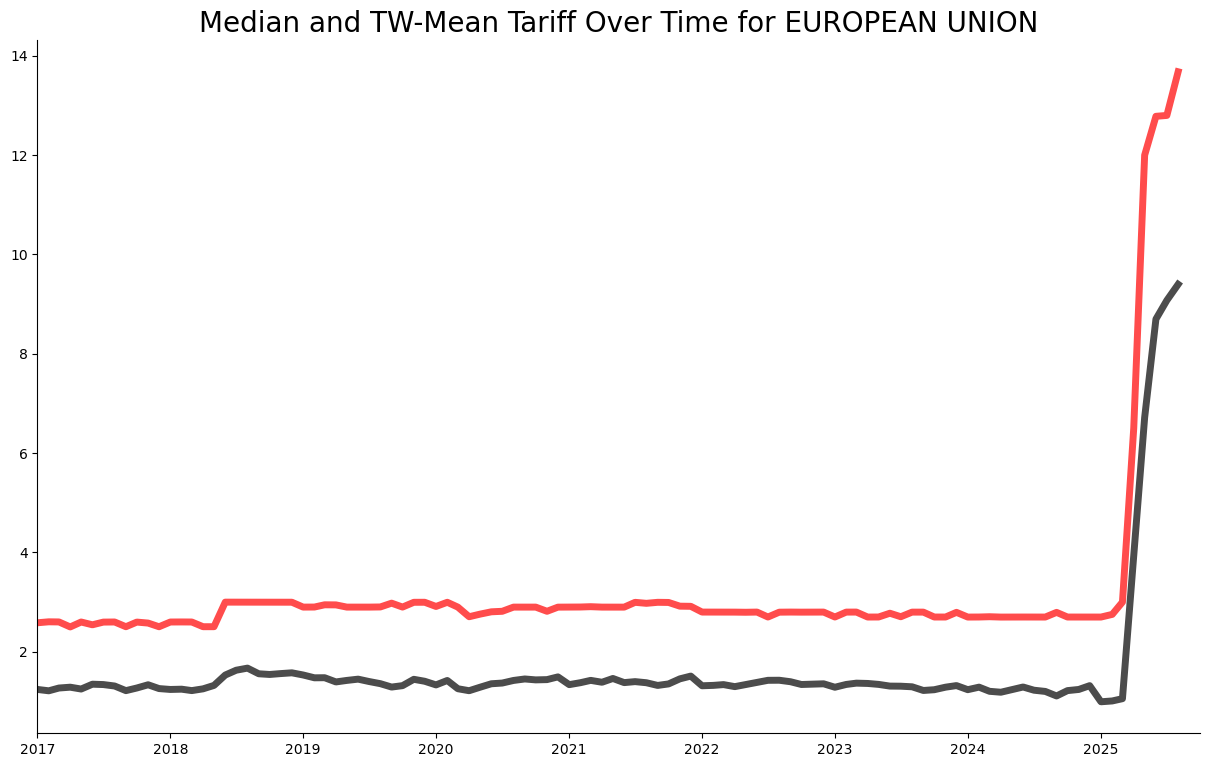

In [71]:
fig, ax = plt.subplots(figsize = (15,9))

ax.plot(mediantariff.index, 100*mediantariff.values, color = "red", alpha = 0.7, linewidth = 5)

ax.plot(tradeweighttariff.index, 100*tradeweighttariff.values, color = "black", alpha = 0.7, linewidth = 5)

ax.set_title("Median and TW-Mean Tariff Over Time for " + df["CTY_NAME"].iloc[0], fontsize = 20)

ax.set_xlim([dt.datetime(2017,1,1), dt.datetime(2025,9,30)])

ax.spines["right"].set_visible(False)

ax.spines["top"].set_visible(False)

plt.show()

In [2]:
my_key = "&key=34e40301bda77077e24c859c6c6c0b721ad73fc7"
# This is my key. I'm nice and I have it posted. If you will be doing more with this
# please get your own key!

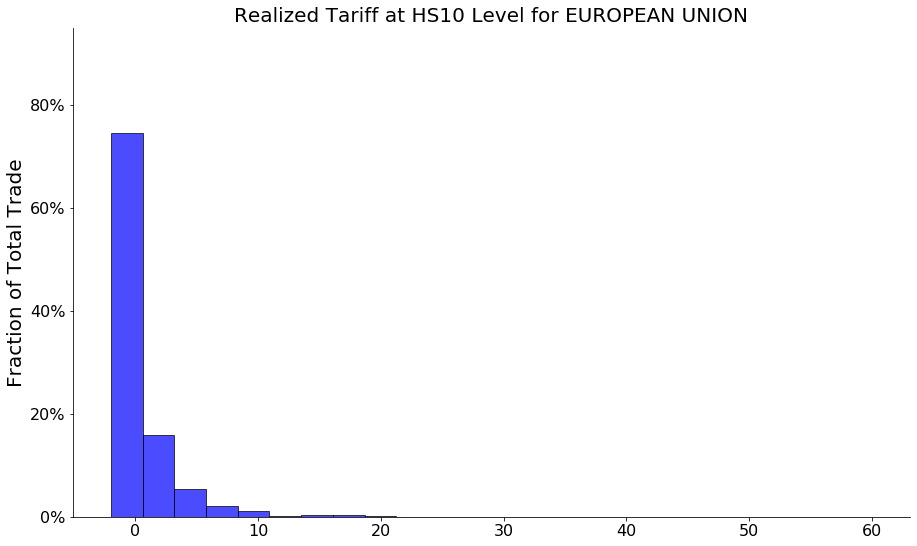

In [53]:
fig, ax = plt.subplots(figsize = (15,9))

bin_edges = np.linspace(-2, 60, 25)  # 50 bins

# Digitize delta_tariff into bins
bin_indices = np.digitize(df["applied_tariff"], bin_edges) - 1

# Sum CON_VAL_MAY in each bin
bin_sums = np.zeros(len(bin_edges) - 1)
for i in range(len(bin_sums)):
    bin_sums[i] = df.loc[bin_indices == i, "CON_VAL_MO"].sum()

# Convert to fraction of total CON_VAL_MAY
fractions = bin_sums / df["CON_VAL_MO"].sum()

ax.bar(bin_edges[:-1], fractions, width=np.diff(bin_edges), align='edge', color='blue', alpha=0.7, edgecolor='black')

ax.set_ylim(top=0.95)

ax.set_ylabel("Fraction of Total Trade", fontsize = 20)

# ax.set_xlabel("Change in HS10 Tariff: May 2025 - May 2024", fontsize = 20)

ax.set_title("Realized Tariff at HS10 Level for " + df["CTY_NAME"].iloc[0], fontsize = 20)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

ax.tick_params(axis='x', labelsize=16)  # Change font size of x-axis tick labels
ax.tick_params(axis='y', labelsize=16)  # Change font size of y-axis tick labels

ax.spines["right"].set_visible(False)

ax.spines["top"].set_visible(False)

plt.show()

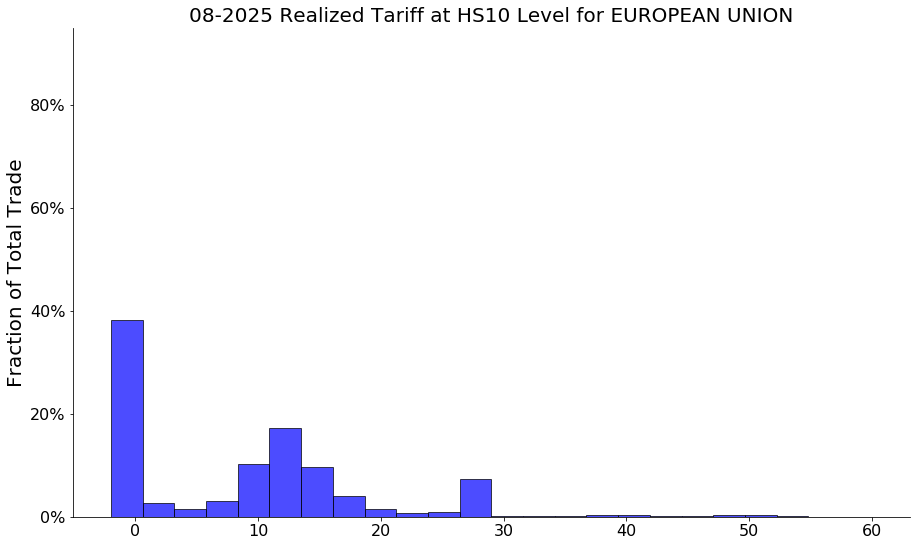

In [ ]:
fig, ax = plt.subplots(figsize = (15,9))

bin_edges = np.linspace(-2, 60, 25)  # 50 bins

# Digitize delta_tariff into bins
bin_indices = np.digitize(df["applied_tariff"], bin_edges) - 1

# Sum CON_VAL_MAY in each bin
bin_sums = np.zeros(len(bin_edges) - 1)
for i in range(len(bin_sums)):
    bin_sums[i] = df.loc[bin_indices == i, "CON_VAL_MO"].sum()

# Convert to fraction of total CON_VAL_MAY
fractions = bin_sums / df["CON_VAL_MO"].sum()

ax.bar(bin_edges[:-1], fractions, width=np.diff(bin_edges), align='edge', color='blue', alpha=0.7, edgecolor='black')

ax.set_ylim(top=0.95)

ax.set_ylabel("Fraction of Total Trade", fontsize = 20)

# ax.set_xlabel("Change in HS10 Tariff: May 2025 - May 2024", fontsize = 20)

ax.set_title("08-2025 Realized Tariff at HS10 Level for " + df["CTY_NAME"].iloc[0], fontsize = 20)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

ax.tick_params(axis='x', labelsize=16)  # Change font size of x-axis tick labels
ax.tick_params(axis='y', labelsize=16)  # Change font size of y-axis tick labels

ax.spines["right"].set_visible(False)

ax.spines["top"].set_visible(False)

plt.show()

In [75]:
foo = df[df["HS2"]  == "30"]

foo[foo["delta_predic_tariff"] > 0.0].sort_values("I_COMMODITY")

,I_COMMODITY,applied_tariff,tariff,CON_VAL_MO,I_COMMODITY_SDESC,time,CTY_NAME,HS2,applied_tariff_2024,CON_VAL_2024,delta_applied_tariff,delta_predic_tariff
11308,3001900150,0.000000,10.0,146873.0,"OTHER GLANDS AND ORGANS, DRIED ETC",2025-05-01,EUROPEAN UNION,30,0.000000,556463.0,0.000000,10.0
11309,3001900190,0.006386,10.0,10006357.0,HEPARIN AND ITS SALTS; OTHER HUMAN OR ANIMAL S...,2025-05-01,EUROPEAN UNION,30,0.000000,7538138.0,0.006386,10.0
11310,3002120010,0.000000,10.0,3131608.0,HUMAN BLOOD PLASMA,2025-05-01,EUROPEAN UNION,30,0.000000,24498654.0,0.000000,10.0
2100,3002120020,0.131807,10.0,1590966.0,"NORMAL HUMAN BLOOD SERA, INCLUDING FREEZE-DRIED",2025-05-01,EUROPEAN UNION,30,0.000000,1281644.0,0.131807,10.0
11311,3002120030,0.000000,10.0,404514.0,HUMAN IMMUNE BLOOD SERA,2025-05-01,EUROPEAN UNION,30,0.000000,188635.0,0.000000,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2444,3006100100,8.779141,10.0,37163829.0,"STERILE SURGICAL CATGUT, SIMILAR STERILE MATER...",2025-05-01,EUROPEAN UNION,30,0.000000,37163713.0,8.779141,10.0
11192,3006400000,9.985585,10.0,25398662.0,DENTAL CEMENTS AND OTHER DENTAL FILLINGS ETC,2025-05-01,EUROPEAN UNION,30,0.000000,32653528.0,9.985585,10.0
2447,3006500000,10.004264,10.0,18762.0,FIRST-AID BOXES AND KITS,2025-05-01,EUROPEAN UNION,30,0.000000,53454.0,10.004264,10.0
2449,3006910000,0.018846,10.0,7142008.0,APPLIANCES IDENTIFIABLE FOR OSTOMY USE,2025-05-01,EUROPEAN UNION,30,0.039467,9065817.0,-0.020621,10.0


In [ ]:
foo

,I_COMMODITY,applied_tariff,tariff,CON_VAL_MO,I_COMMODITY_SDESC,time,CTY_NAME,HS2,applied_tariff_2024,CON_VAL_2024,delta_applied_tariff,delta_predic_tariff
0,0101210010,3.975665,10.0,2489898.0,"HORSES, LIVE, PUREBRED BREEDING MALE",2025-05-01,EUROPEAN UNION,01,0.0,2344690.0,3.975665,10.0
1,0101210020,10.000026,10.0,756408.0,"HORSES, LIVE, PUREBRED BREEDING FEMALE",2025-05-01,EUROPEAN UNION,01,0.0,2914481.0,10.000026,10.0
2,0101290090,9.352150,10.0,27010378.0,"HORSES, LIVE, NESOI",2025-05-01,EUROPEAN UNION,01,0.0,22674634.0,9.352150,10.0
3,0106199120,9.999825,10.0,800824.0,"DOGS, LIVE",2025-05-01,EUROPEAN UNION,01,0.0,1732288.0,9.999825,10.0
4,0106199195,9.999817,10.0,273275.0,"MAMMALS, LIVE, NESOI",2025-05-01,EUROPEAN UNION,01,0.0,135082.0,9.999817,10.0


In [ ]:
# country = "4120"

# month = "05"

# dfmay = get_hs10_data_month("2025", month , country)

# print( dfmay["CAL_DUT_MO"].sum() / dfmay["CON_VAL_MO"].sum() * 100)

# print(dfmay["tariff"].median())

# df = get_hs10_data_month("2024", month , country)

# print( df["CAL_DUT_MO"].sum() / df["CON_VAL_MO"].sum() * 100)

# print(df["tariff"].median())

# dfmay.rename(columns={"CON_VAL_MO": "CON_VAL_MAY", "tariff": "tariff_MAY"}, inplace=True)

# df = pd.merge(dfmay[["I_COMMODITY", "tariff_MAY", "CON_VAL_MAY"]], 
#               df[["I_COMMODITY", "tariff", "CON_VAL_MO"]], how="inner", on=["I_COMMODITY"])

# df["delta_tariff"] = df["tariff_MAY"] - df["tariff"]

<Response [200]>
6.871199317834926
11.598546970118683
<Response [200]>
0.9559805314254074
2.499949808267582


In [123]:
dfmay["CTY_NAME"].iloc[0]

'UNITED KINGDOM'

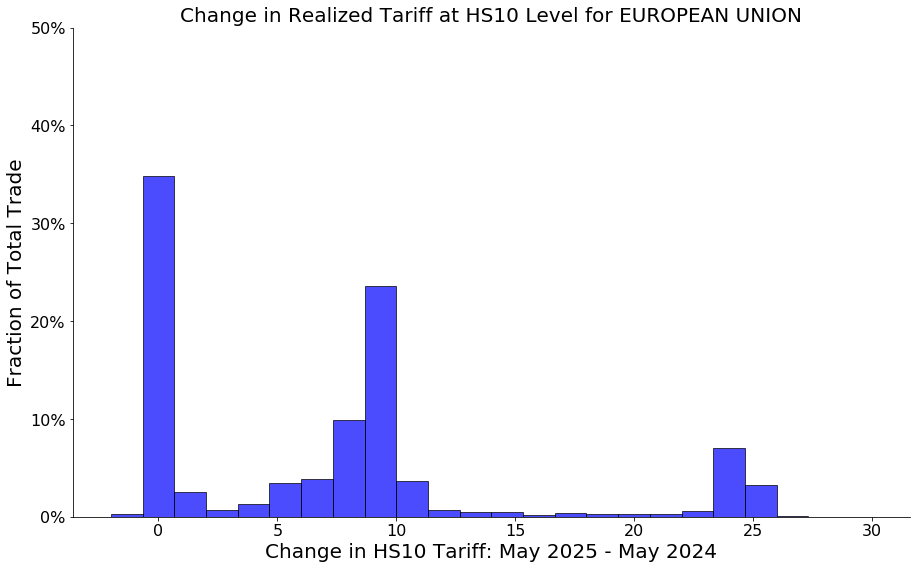

In [37]:
fig, ax = plt.subplots(figsize = (15,9))

bin_edges = np.linspace(-2, 30, 25)  # 50 bins


# Digitize delta_tariff into bins
bin_indices = np.digitize(df["delta_applied_tariff"], bin_edges) - 1

# Sum CON_VAL_MAY in each bin
bin_sums = np.zeros(len(bin_edges) - 1)
for i in range(len(bin_sums)):
    bin_sums[i] = df.loc[bin_indices == i, "CON_VAL_2024"].sum()

# Convert to fraction of total CON_VAL_MAY
fractions = bin_sums / df["CON_VAL_2024"].sum()

ax.bar(bin_edges[:-1], fractions, width=np.diff(bin_edges), align='edge', color='blue', alpha=0.7, edgecolor='black')

ax.set_ylim(top=0.50)

ax.set_ylabel("Fraction of Total Trade", fontsize = 20)

ax.set_ylabel("Fraction of Total Trade", fontsize = 20)

ax.set_xlabel("Change in HS10 Tariff: May 2025 - May 2024", fontsize = 20)

ax.set_title("Change in Realized Tariff at HS10 Level for " + df["CTY_NAME"].iloc[0], fontsize = 20)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

ax.tick_params(axis='x', labelsize=16)  # Change font size of x-axis tick labels
ax.tick_params(axis='y', labelsize=16)  # Change font size of y-axis tick labels

ax.spines["right"].set_visible(False)

ax.spines["top"].set_visible(False)

plt.show()

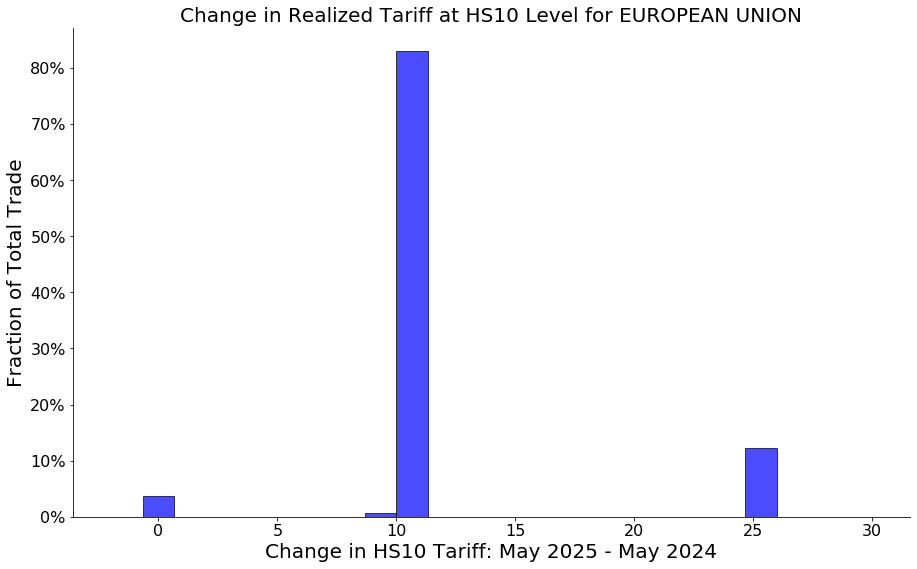

In [41]:
fig, ax = plt.subplots(figsize = (15,9))

bin_edges = np.linspace(-2, 30, 25)  # 50 bins


# Digitize delta_tariff into bins
bin_indices = np.digitize(df["delta_predic_tariff"], bin_edges) - 1

# Sum CON_VAL_MAY in each bin
bin_sums = np.zeros(len(bin_edges) - 1)
for i in range(len(bin_sums)):
    bin_sums[i] = df.loc[bin_indices == i, "CON_VAL_MO"].sum()

# Convert to fraction of total CON_VAL_MAY
fractions = bin_sums / df["CON_VAL_MO"].sum()

ax.bar(bin_edges[:-1], fractions, width=np.diff(bin_edges), align='edge', color='blue', alpha=0.7, edgecolor='black')

# ax.set_ylim(top=0.50)

ax.set_ylabel("Fraction of Total Trade", fontsize = 20)

ax.set_ylabel("Fraction of Total Trade", fontsize = 20)

ax.set_xlabel("Change in HS10 Tariff: May 2025 - May 2024", fontsize = 20)

ax.set_title("Change in Realized Tariff at HS10 Level for " + df["CTY_NAME"].iloc[0], fontsize = 20)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

ax.tick_params(axis='x', labelsize=16)  # Change font size of x-axis tick labels
ax.tick_params(axis='y', labelsize=16)  # Change font size of y-axis tick labels

ax.spines["right"].set_visible(False)

ax.spines["top"].set_visible(False)

plt.show()

In [70]:
df_positive_tolerance.sort_values(by=["CON_VAL_MAY"], ascending=False, inplace=True)

df_positive_tolerance.head(50)

c:\ProgramData\Anaconda3\lib\site-packages\pandas\util\_decorators.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return func(*args, **kwargs)


,I_COMMODITY,tariff_MAY,CON_VAL_MAY,tariff,CON_VAL_MO,delta_tariff
3542,9801001028,0.000000,359074871.0,0.000000,104883257.0,0.000000e+00
458,3002140010,0.000000,175196434.0,0.000000,6282742.0,0.000000e+00
612,3004909221,0.000000,142106974.0,0.000000,133143092.0,0.000000e+00
513,3004909234,0.000000,134107750.0,0.000000,3734623.0,0.000000e+00
3056,3004909215,0.006368,116343417.0,0.000000,489778466.0,6.368216e-03
467,3002150011,0.000000,73353249.0,0.000000,12012511.0,0.000000e+00
973,7108121013,0.000000,62813880.0,0.000000,26782353.0,0.000000e+00
3543,9801001030,0.000000,49726286.0,0.000000,59064360.0,0.000000e+00
2470,9021500000,0.001815,48694821.0,0.000000,41675681.0,1.815388e-03
468,3002150091,0.000000,40389701.0,0.000000,319736792.0,0.000000e+00
